Simulating for Euclidean Geometry...


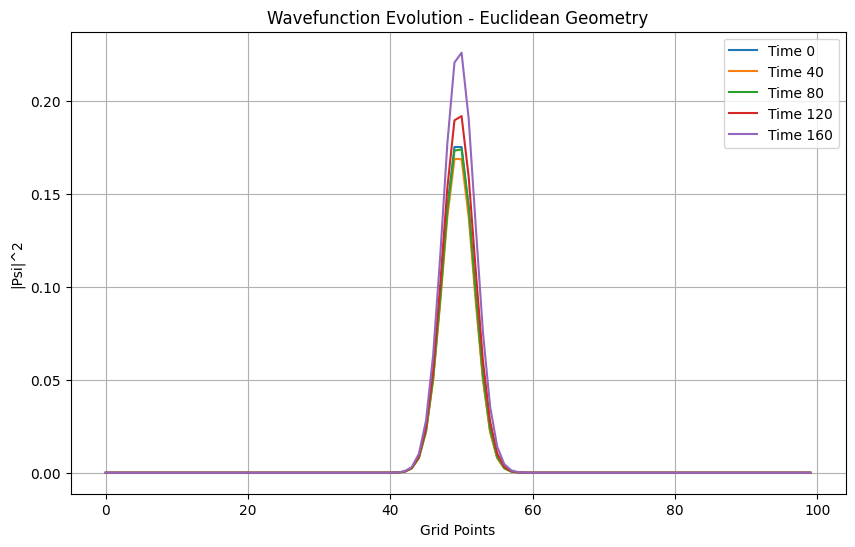

Simulating for Hyperbolic Geometry...


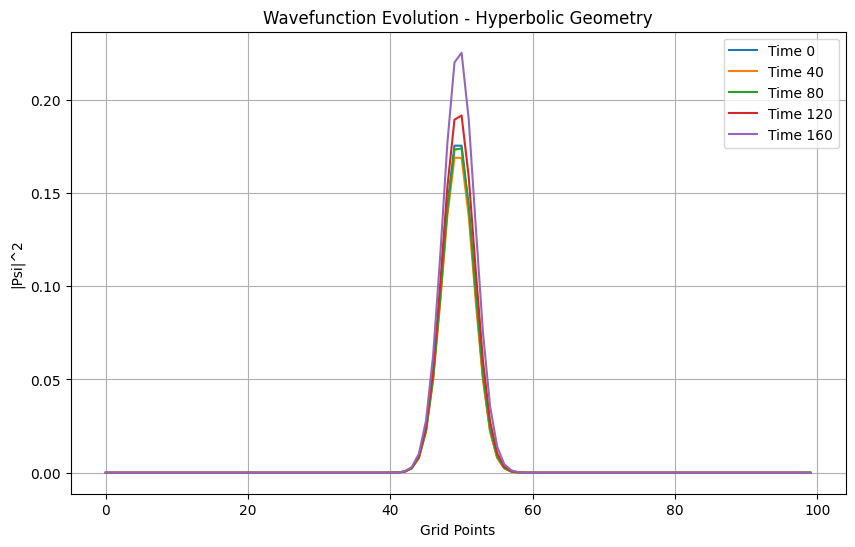

Simulating for Spherical Geometry...


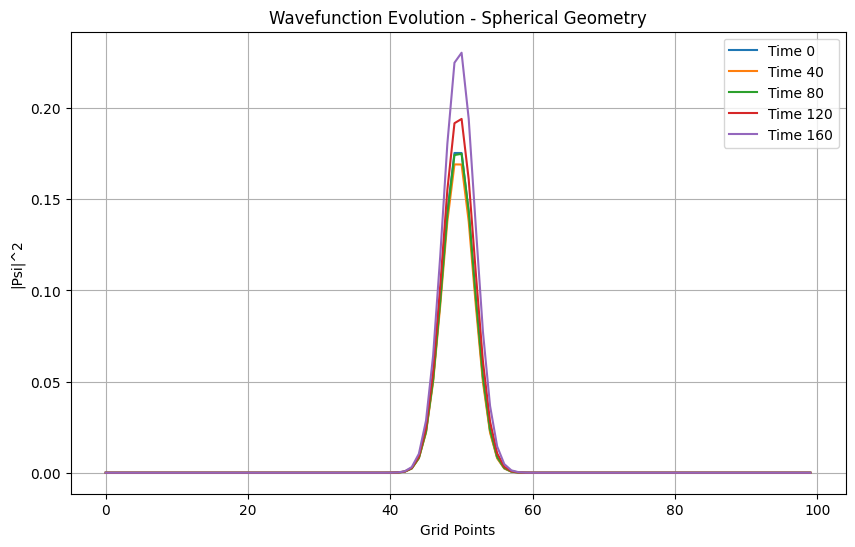

Simulating for Fractal Geometry...


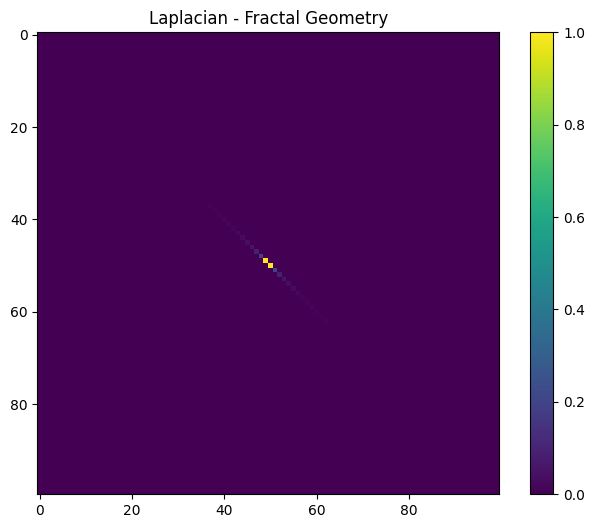

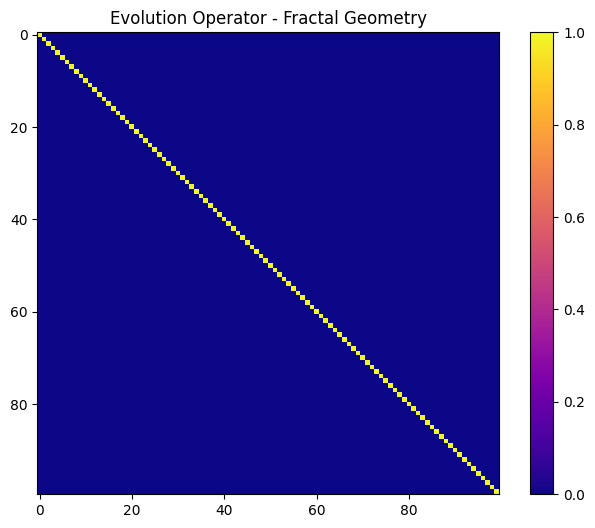

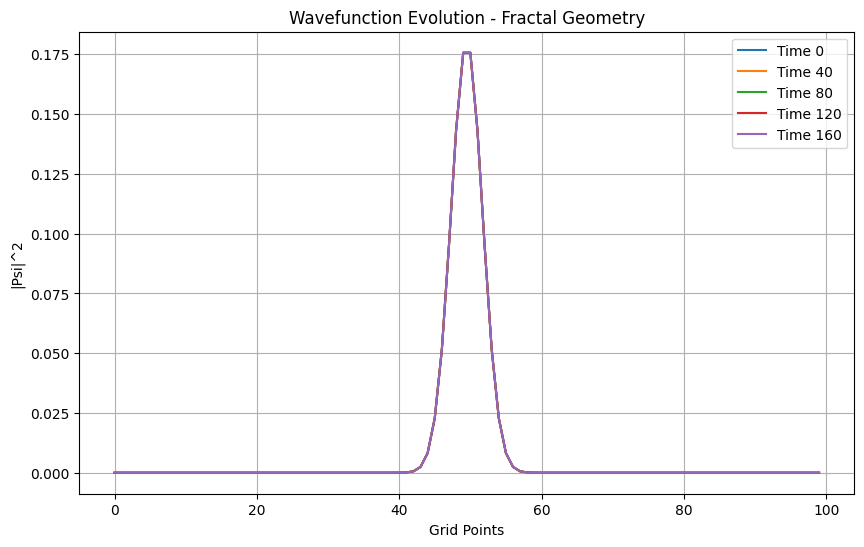

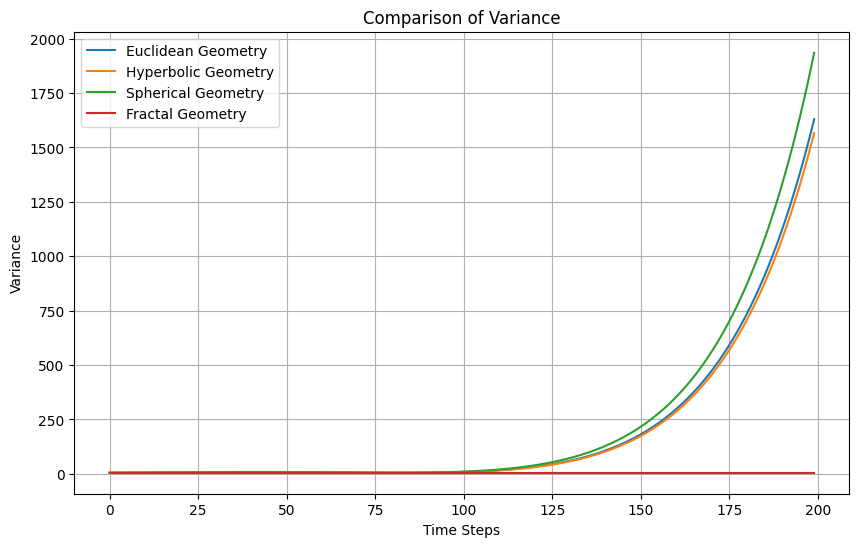

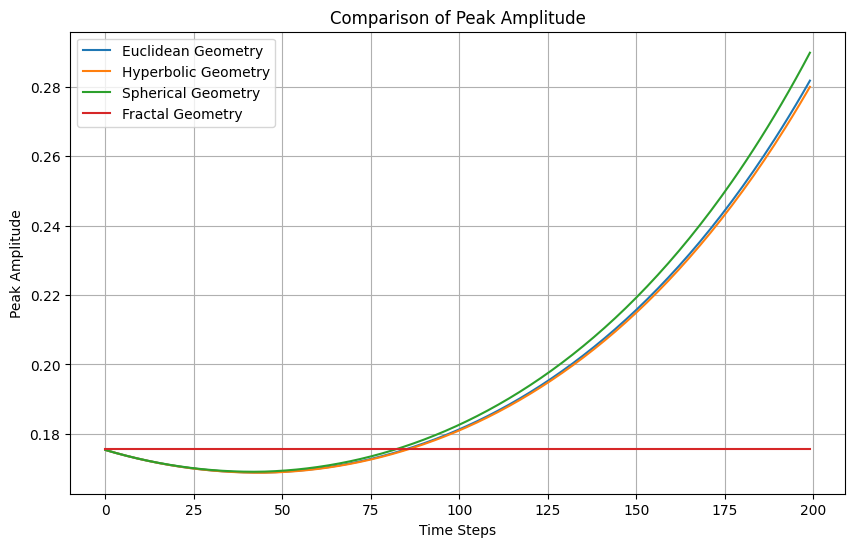

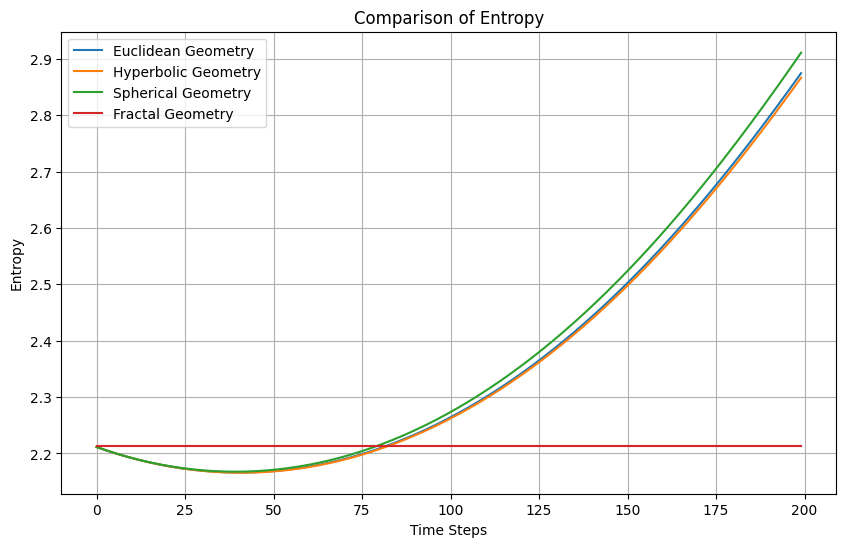

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import diags
from scipy.linalg import expm

# Constants
GRID_SIZE = 100  # Size of the 2D grid
TIME_STEPS = 200  # Number of time steps
DELTA_X = 1.0  # Spatial resolution
DELTA_T = 0.01  # Time step
H_BAR = 1.0  # Reduced Planck's constant
MASS = 1.0  # Mass of the particle
CURVATURE_TYPES = ["Euclidean", "Hyperbolic", "Spherical", "Fractal"]

# Fractal Laplacian
def fractal_laplacian(grid_size, fractal_dimension=1.5):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    # Fractal scaling: power-law weights for connections
    fractal_weights = np.abs(np.linspace(-grid_size // 2, grid_size // 2, grid_size)) ** (-fractal_dimension)
    fractal_weights /= np.max(fractal_weights)  # Normalize weights
    laplacian *= np.diag(fractal_weights)

    return laplacian / (DELTA_X**2)

# Laplacian operator for different geometries
def laplacian_operator(grid_size, curvature="Euclidean"):
    diagonal = np.ones(grid_size)
    off_diagonal = np.ones(grid_size - 1)
    laplacian = diags([diagonal, -2 * diagonal, diagonal], [0, -1, 1]).toarray()

    if curvature == "Hyperbolic":
        # Exponential scaling for hyperbolic curvature
        laplacian -= np.diag(np.exp(np.linspace(-1, -2, grid_size)))
    elif curvature == "Spherical":
        # Linear scaling for spherical curvature
        laplacian += np.diag(np.linspace(1, 1 / grid_size, grid_size))
    elif curvature == "Fractal":
        # Use fractal Laplacian
        return fractal_laplacian(grid_size)

    return laplacian / (DELTA_X**2)

# Initialize wavefunction
def initialize_wavefunction(grid_size):
    x = np.linspace(-grid_size // 2, grid_size // 2, grid_size)
    psi = np.exp(-(x**2) / 20.0) * np.exp(1j * 2.0 * np.pi * x / grid_size)
    return psi / np.linalg.norm(psi)

# Time evolution of the wavefunction
def evolve_wavefunction(psi, laplacian, time_steps, delta_t):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    psi_t = []

    for _ in range(time_steps):
        psi = evolution_operator @ psi
        psi_t.append(np.abs(psi)**2)

    return np.array(psi_t)

# Calculate quantitative metrics
def calculate_metrics(psi_t):
    variances = []
    peak_amplitudes = []
    entropies = []

    for prob_density in psi_t:
        # Variance
        x = np.arange(len(prob_density))
        mean = np.sum(x * prob_density)
        variance = np.sum(((x - mean) ** 2) * prob_density)
        variances.append(variance)

        # Peak amplitude
        peak_amplitude = np.max(prob_density)
        peak_amplitudes.append(peak_amplitude)

        # Shannon entropy
        entropy = -np.sum(prob_density * np.log(prob_density + 1e-12))
        entropies.append(entropy)

    return variances, peak_amplitudes, entropies

# Plot metrics
def plot_metrics(metrics, curvature_type, metric_name):
    plt.figure(figsize=(10, 6))
    for metric, label in zip(metrics, ["Variance", "Peak Amplitude", "Entropy"]):
        plt.plot(metric, label=label)
    plt.title(f"{metric_name} - {curvature_type} Geometry")
    plt.xlabel("Time Steps")
    plt.ylabel(metric_name)
    plt.legend()
    plt.grid()
    plt.show()

# Plot wavefunction evolution
def plot_results(psi_t, curvature_type):
    plt.figure(figsize=(10, 6))
    for t in range(0, len(psi_t), len(psi_t) // 5):
        plt.plot(psi_t[t], label=f"Time {t}")
    plt.title(f"Wavefunction Evolution - {curvature_type} Geometry")
    plt.xlabel("Grid Points")
    plt.ylabel("|Psi|^2")
    plt.legend()
    plt.grid()
    plt.show()

# Visualize Laplacian
def visualize_laplacian(laplacian, title):
    plt.figure(figsize=(8, 6))
    plt.imshow(laplacian, cmap="viridis")
    plt.colorbar()
    plt.title(title)
    plt.show()

# Visualize Evolution Operator
def visualize_evolution_operator(laplacian, delta_t, title):
    hamiltonian = -H_BAR**2 / (2 * MASS) * laplacian
    evolution_operator = expm(-1j * hamiltonian * delta_t / H_BAR)
    plt.figure(figsize=(8, 6))
    plt.imshow(np.abs(evolution_operator), cmap="plasma")
    plt.colorbar()
    plt.title(f"Evolution Operator - {title}")
    plt.show()

# Main experiment
def main():
    all_metrics = {}

    for curvature_type in CURVATURE_TYPES:
        print(f"Simulating for {curvature_type} Geometry...")
        laplacian = laplacian_operator(GRID_SIZE, curvature=curvature_type)

        # Verify Laplacian
        if curvature_type == "Fractal":
            visualize_laplacian(laplacian, f"Laplacian - {curvature_type} Geometry")
            visualize_evolution_operator(laplacian, DELTA_T, f"{curvature_type} Geometry")

        psi = initialize_wavefunction(GRID_SIZE)
        psi_t = evolve_wavefunction(psi, laplacian, TIME_STEPS, DELTA_T)

        # Calculate metrics
        variances, peak_amplitudes, entropies = calculate_metrics(psi_t)
        all_metrics[curvature_type] = {
            "Variance": variances,
            "Peak Amplitude": peak_amplitudes,
            "Entropy": entropies,
        }

        # Plot evolution
        plot_results(psi_t, curvature_type)

    # Compare metrics
    for metric_name in ["Variance", "Peak Amplitude", "Entropy"]:
        plt.figure(figsize=(10, 6))
        for curvature_type in CURVATURE_TYPES:
            plt.plot(
                all_metrics[curvature_type][metric_name],
                label=f"{curvature_type} Geometry",
            )
        plt.title(f"Comparison of {metric_name}")
        plt.xlabel("Time Steps")
        plt.ylabel(metric_name)
        plt.legend()
        plt.grid()
        plt.show()

if __name__ == "__main__":
    main()